## Initialise Instruments

In [2]:
#PC notebook
import qkit #filepath = r'C:\Users\weideslab-admin\AppData\Roaming\Python\Python313\site-packages\qkit\drivers

qkit.cfg['load_visa'] = True
qkit.cfg['datafolder_structure'] = 2
# New Qkit does not create folder. Must be done before run! (think a txt doc is created which causes this)
qkit.cfg['datadir'] = r'd:\notebooks\James'
qkit.cfg['run_id'] = 'results_h5'
qkit.cfg['user'] = 'James'
qkit.start()

from qkit.measure.spectroscopy import spectroscopy
from qkit.storage.store import Data
import qkit.measure.samples_class as sc
from qkit.analysis.circle_fit.circle_fit_2019 import circuit

# Uses SciPy for signal processing and curve fitting
from scipy import signal as sg
from scipy.optimize import curve_fit
import qkit.analysis.qfit as qfit

from importlib import reload
import qkit.gui.notebook.Progress_Bar as Pb
import qkit.measure.spectroscopy.spectroscopy as spectroscopy
from importlib import reload
import time

# import skrf as rf
import pyvisa as visa
from tqdm import tqdm
import requests

import mcculw # DAQ 
# import mcculw.ul
from attenuatorControl import ldacontroller #Dependency: import 'attenuatorControl' folder from existing working folders

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.animation import FuncAnimation
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

import os
import re
import sys
import io



Lazy-Loading configuration...
QKIT configuration initialized -> available as qkit.cfg[...]
Starting QKIT framework ... -> qkit.core.startup
Loading module ... S10_logging.py
Loading module ... S14_setup_directories.py
Loading module ... S16_available_modules.py
Loading module ... S20_check_for_updates.py
Loading module ... S25_info_service.py
Loading module ... S30_qkit_start.py
Loading module ... S65_load_RI_service.py
Loading module ... S70_load_visa.py


C:\Users\weideslab-admin\AppData\Roaming\Python\Python313\site-packages\qkit\core\s_init\S70_load_visa.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


Loading module ... S80_load_file_service.py
Loading module ... S85_init_measurement.py


Loading module ... S98_started.py
Loading module ... S99_init_user.py
Initialized the file info database (qkit.fid) in 0.432 seconds.


### Instrument setup

In [ ]:
rm = visa.ResourceManager() # Initialize the VISA library
resources = rm.list_resources() # List available VISA resources

for resource in resources: # Print the list of resources
    print(resource)

In [ ]:
# vna = qkit.instruments.create('vna', 'RS_VNA_ZNLXXX', address='GPIB0::20::INSTR') #R&S VNA via GPIB cable
#vna2 = qkit.instruments.create('vna2','RS_VNA_ZNLXXX',address='TCPIP::10.22.197.110::hislip0::INSTR') #R&S VNA via ethernet cable
#vna = vna2

#caen = qkit.instruments.create('caen', 'Caen_FAST_PS', address='10.22.197.101')
caen2040 = qkit.instruments.create('caen2', 'Caen_FAST_PS', address='10.22.197.103')

In [ ]:
#ldacontroller.CLI_Vaunix_Attn().main(['-c', '1', '-a', '10'])

In [ ]:
smpl = sc.Sample() # creates sample object (i.e., container for metadata)
s = spectroscopy.spectrum(vna = vna, exp_name = '', sample = smpl)

## Restart Instruments

In [ ]:
vna.set_bandwidth(500)
vna.set_power(-20)
vna.set_startfreq(6.2e9) 
vna.set_stopfreq(6.45e9)
vna.set_nop(500)
vna.set_averages(1)
vna.set_sweep_mode('cont')

In [ ]:
#ldacontroller.CLI_Vaunix_Attn().main(['-i', '32186', '-c', '1', '-a', str(0)])
#vna.set_sweep_mode('hold')
#caen.off()
caen2040.off()


In [ ]:
caen2040.ramp_current(0.0, 1)
caen2040.off()

## FPGA Startup

### FPGA class

5/10/26: Based on need to do understand the operation and need to perform complex tasks with the FPGA, an FPGA class should be made. 

The FPGA class should be based on communication via flask server, the fpga should be perform a measurement and send the data to the PC for the PC to process*.

*Even though the FPGA is capable of doing data processing, splitting the workload across both the PC and the FPGA is impractical and gives rise to parity issues, this is an issue that can be amplified as it is an arbitrary process made susceptible to user preference with no straightforward way to resolve. 

## test code



In [15]:
from fpga_client import FPGAClient

fpga = FPGAClient(fpga_ip="10.22.197.200", port = '5555') #FPGA ip
#fpga = FPGAClient(fpga_ip="127.0.0.1") #localhost ip for testing

print(f"status: {fpga.status()}")
GEN_CH = 1
RO_CH = 1


config = {
    "res_ch": GEN_CH,
    "ro_chs": [RO_CH],
    "reps": 1,
    "relax_delay": 1.0,
    "res_phase": 0,
    "pulse_style": "const",
    "sigma": 50,
    "length": 300,
    "readout_length": 100,
    "pulse_gain": 40000,
    "adc_trig_offset": 250,
    "soft_avgs": 200
}

fpga.configure(config)

fpga.set_frequency(6000)

iq = fpga.measure()

print(iq.shape)

I = np.real(iq)
Q = np.imag(iq)

magnitude = np.abs(iq)
phase = np.angle(iq)
print(magnitude[50])

status: {'status': 'ok', 'data': {'connected': True, 'frequency': 6000, 'configured': True}}
(100,)
12.623314


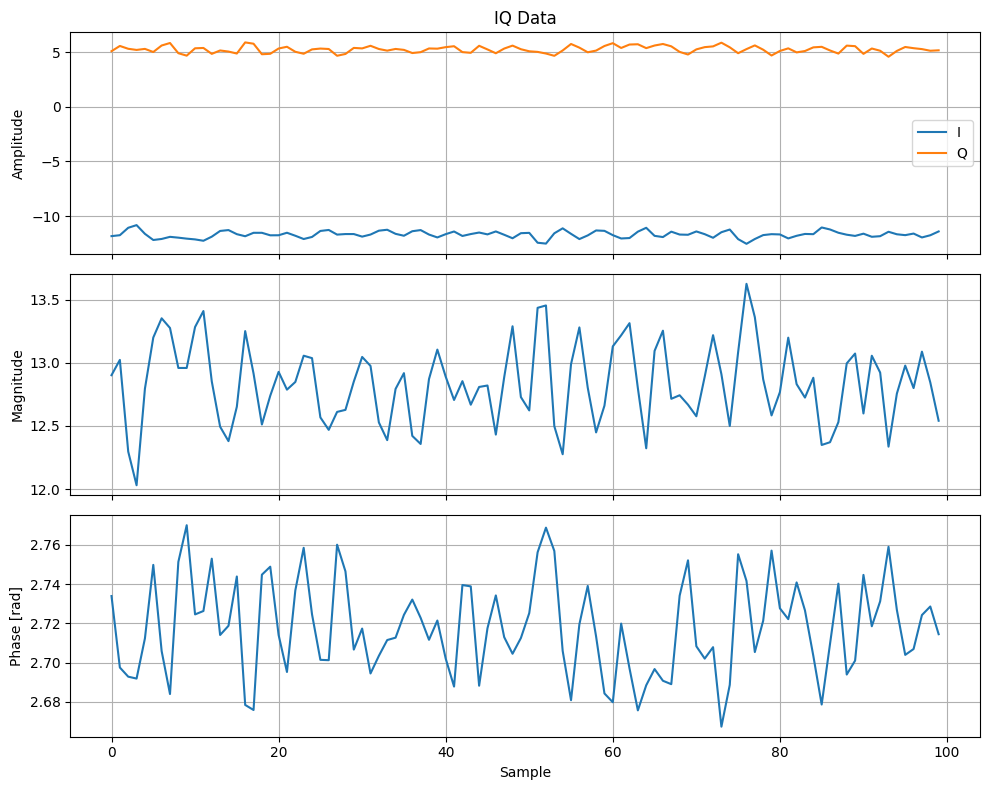

In [16]:

# IQ components
I = np.real(iq)
Q = np.imag(iq)

# Magnitude and phase
magnitude = np.abs(iq)
phase = np.angle(iq)

# Sample index
samples = np.arange(len(iq))

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# I and Q
ax[0].plot(samples, I, label="I")
ax[0].plot(samples, Q, label="Q")
ax[0].set_ylabel("Amplitude")
ax[0].set_title("IQ Data")
ax[0].legend()
ax[0].grid(True)

# Magnitude
ax[1].plot(samples, magnitude)
ax[1].set_ylabel("Magnitude")
ax[1].grid(True)

# Phase
ax[2].plot(samples, phase)
ax[2].set_xlabel("Sample")
ax[2].set_ylabel("Phase [rad]")
ax[2].grid(True)

plt.tight_layout()
plt.show()
